# IPA27 - Fase 1: Carga, Preparación y Consolidación de Datos



Este notebook constituye el **primer bloque** del pipeline de procesamiento del **Índice de Prosperidad Andaluz (IPA27)**.



### Funciones de este bloque:

1. **Carga de Datos**: Importación de todos los indicadores desde el archivo Excel consolidado de salida (`results/data/ipa27_raw_YYYYMMDD.xlsx`).

2. **Alineación de Frecuencias**: Clasificación de las series temporales por frecuencias (Mensual, Trimestral y Anual).

3. **Registro de Trazabilidad**: Generación del registro inicial (`AUDIT_REGISTRY`) para control de auditoría.

4. **Deflactación y Ajuste de Moneda**: Transformación de Renta Disponible Bruta (`ECO_RBH`) y Costes Salariales (`ECO_COL_sal`) a términos reales usando el IPC rebasado.

5. **Imputación de Vacíos Regionales**: Red de seguridad para rellenar faltantes utilizando la serie nacional (`ESP`) como proxy.

6. **Cálculo de Variables de Escala**: Interpolación de poblaciones y cálculo de Renta per cápita (`ECO_RBHpc`).

7. **Diagnóstico Temporal**: Inventariado de la cobertura e identificación de necesidades de nowcasting o trimestralización por indicador.



Al finalizar, se guardan los DataFrames consolidados en archivos CSV intermedios en `data/processed/` para ser consumidos por el bloque de modelación (`02_2_modelacion.ipynb`).


## 📁 0. Respaldo Automático de Procesados Previos (Gobernanza de Históricos)

Antes de iniciar el procesamiento con el nuevo consolidado raw, esta sección identifica la versión raw anterior utilizada (vintage previo) y **pone a resguardo en una carpeta histórica todos los archivos previamente procesados** (`data/processed/`), garantizando la preservación completa e inalterada de ejecuciones pasadas.

In [2]:
# %% CELDA 0B: RESPALDO DE PROCESADOS HISTÓRICOS PREVIOS
import os
import glob
import shutil
import re

# Asegurar que trabajamos desde la raíz del proyecto
if os.getcwd().endswith('notebooks'):
    os.chdir('..')

print("=" * 60)
print("🛡️ GOBERNANZA DE HISTÓRICOS: RESPALDO DE EJECUCIONES ANTERIORES")
print("=" * 60)

raw_files = sorted(glob.glob('results/data/ipa27_raw_*.xlsx'))

if len(raw_files) >= 2:
    prev_raw = raw_files[-2]
    curr_raw = raw_files[-1]
    
    match = re.search(r'ipa27_raw_(\d+)\.xlsx', os.path.basename(prev_raw))
    prev_tag = match.group(1) if match else os.path.basename(prev_raw).replace('.xlsx', '')
    
    backup_dir = os.path.join('data', 'processed_history', f'ipa27_raw_{prev_tag}')
    processed_dir = os.path.join('data', 'processed')
    
    if os.path.exists(processed_dir):
        files_to_backup = [f for f in os.listdir(processed_dir) if os.path.isfile(os.path.join(processed_dir, f))]
        
        if files_to_backup:
            os.makedirs(backup_dir, exist_ok=True)
            for file_name in files_to_backup:
                src = os.path.join(processed_dir, file_name)
                dst = os.path.join(backup_dir, file_name)
                shutil.copy2(src, dst)
            print(f"📦 Respaldo histórico creado con éxito en: '{backup_dir}'")
            print(f"   Archivos resguardados ({len(files_to_backup)}): {files_to_backup}")
        else:
            print(f"ℹ️ La carpeta '{processed_dir}' está vacía. No hay archivos previos que respaldar.")
    else:
        print(f"ℹ️ No existe la carpeta '{processed_dir}'. Se creará nueva en esta ejecución.")
        
    print(f"📌 Raw Anterior Resguardado: {os.path.basename(prev_raw)}")
    print(f"🚀 Raw Activo para esta Ejecución: {os.path.basename(curr_raw)}")
else:
    print(f"ℹ️ No se detectó un archivo raw previo para respaldar en {os.getcwd()} (archivos hallados: {raw_files}).")

🛡️ GOBERNANZA DE HISTÓRICOS: RESPALDO DE EJECUCIONES ANTERIORES
📦 Respaldo histórico creado con éxito en: 'data\processed_history\ipa27_raw_20260603'
   Archivos resguardados (9): ['Banda_Ancha.csv', 'IPA27_Master_Table.csv', 'IPA27_Results.xlsx', 'ipa27_prep_mensual.csv', 'ipa27_prep_trimestral.csv', 'ipa27_prep_anual.csv', 'ipa27_modeled_raw.csv', 'ipa27_audit_registry.pkl', 'cgpj_violencia_mujer.csv']
📌 Raw Anterior Resguardado: ipa27_raw_20260603.xlsx
🚀 Raw Activo para esta Ejecución: ipa27_raw_20260820.xlsx


In [3]:
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL
from scipy.interpolate import CubicSpline
from datetime import datetime

warnings.filterwarnings('ignore')

# Asegurar que trabajamos desde la raíz del proyecto
if os.getcwd().endswith('notebooks'):
    os.chdir('..')
    print(f"🏠 Directorio de trabajo: {os.getcwd()}")

# Configuración visual
pd.set_option('display.max_columns', 50)
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 9

# === REGIONES (17 CCAA + ESPAÑA) ===
REGIONES = ['ESP', 'AND', 'ARA', 'AST', 'BAL', 'CAN', 'CANT', 'CYL', 'CLM', 'CAT', 'VAL', 'EXT', 'GAL', 'MAD', 'MUR', 'NAV', 'PV', 'RIO']

# === RUTAS ===
def get_latest_vintage():
    files = glob.glob('results/data/ipa27_raw_*.xlsx')
    if not files:
        fallback = 'results/data/ipa27_raw.xlsx'
        return fallback if os.path.exists(fallback) else None
    return sorted(files)[-1]

FILEPATH = get_latest_vintage()
if FILEPATH:
    print(f"📂 Utilizando vintage: {FILEPATH}")
else:
    print("❌ No se encontró ningún archivo ipa27_raw_*.xlsx en results/data/")

# === OBJETIVO TEMPORAL ===
Q_OBJETIVO = pd.Period('2026Q2', freq='Q')

# === INDICADORES A DESESTACIONALIZAR ===
DESEST_MENSUAL = ['EMP_SOC', 'INF_TRA', 'INV_HIP', 'SOC_ASO', 'CON_OCI']
DESEST_TRIMESTRAL = ['ECO_COL_sal','LIB_SEX', 'SEG_BAL', 'SEG_CRI', 'VID_PAR']

# === NORMALIZACIÓN PER CÁPITA ===
PER_CAPITA_CONFIG = {
    'SEG_BAL': 'POB',
    'SEG_CRI': 'POB',
    'LIB_SEX': 'POB',
    'LIB_ODI': 'POB',
    'EDU_SUP': 'POB',
    'EMP_SOC': 'POB',
    'EMP_NAT': 'POB',
    'INV_HIP': 'POB',
    'INF_TRA': 'POB',
    'SOC_ASO': 'POB',
    'CON_OCI': 'POB',   # ← CAMBIADO: Afiliados = personas, dividir por población
    'INV_IED': 'PIB',   # Mantener, pero arreglar la lógica abajo
}

# === CHOW-LIN: INDICADORES RELACIONADOS ===
CHOWLIN_CONFIG = {
    'CON_IDI': {'rel': 'ECO_RBHpc', 'tipo': 'stock'},      # % PIB → media
    'EDU_ABA': {'rel': 'EDU_SUP', 'tipo': 'stock'},      # % abandono → media
    'EMP_NAT': {'rel': 'INF_TRA', 'tipo': 'flujo'},      # nacimientos → suma
    'INF_BAN': {'rel': 'EDU_SUP', 'tipo': 'stock'},      # % bancarización → media
    'LIB_ODI': {'rel': 'SEG_CRI', 'tipo': 'flujo'},      # delitos → suma
    'SAL_ESP': {'rel': 'ECO_RBHpc', 'tipo': 'stock'},      # años vida → media
    'SOC_PAR_enlazado': {'rel': 'EMP_SOC', 'tipo': 'stock'},  # % participación → media
    'VID_ARO': {'rel': 'EDU_SUP', 'tipo': 'stock'},      # % AROPE → media
}

# === INDICADORES A INVERTIR (menor es mejor) ===
INVERTIR = ['SEG_BAL', 'SEG_CRI', 'LIB_ODI', 'LIB_SEX', 'GOB_EFF', 'GOB_DES']

# === ESTRUCTURA JERÁRQUICA ===
# Corrección: Usamos GOB_EFF en lugar de GOB_TRA
ESTRUCTURA = {
    'Sociedades Inclusivas': {
        '1. Seguridad': ['SEG_BAL', 'SEG_CRI'],
        '2. Libertad': ['LIB_ODI', 'LIB_SEX'],
        '3. Gobernanza': ['GOB_DES', 'GOB_EFF'],
        '4. Capital Social': ['SOC_ASO', 'SOC_PAR_enlazado'],
    },
    'Economías Abiertas': {
        '5. Inversión': ['INV_HIP', 'INV_IED'],
        '6. Empresas': ['EMP_NAT', 'EMP_SOC'],
        '7. Infraestructura': ['INF_BAN', 'INF_TRA'],
        '8. Calidad Económica': ['ECO_RBHpc', 'ECO_COL_sal'], 
    },
    'Personas Empoderadas': {
        '9. Vida': ['VID_ARO', 'VID_PAR'],
        '10. Salud': ['SAL_ESP', 'SAL_SAT_enlazado'],
        '11. Educación': ['EDU_ABA', 'EDU_SUP'],
        '12. Conocimiento': ['CON_IDI', 'CON_OCI'],
    }
}

print("✓ Configuración cargada")


📂 Utilizando vintage: results/data\ipa27_raw_20260820.xlsx
✓ Configuración cargada


## 1. Carga de Datos

Cargamos las hojas del Excel consolidado, que ahora incluyen datos para las 18 regiones (17 CC.AA. + España).
Debido a que algunas hojas pueden contener periodos con diferentes frecuencias (ej. Trimestral y Anual), aplicamos un filtro por formato de periodo para separar los datos correctamente.

In [4]:
# %% CELDA 2: CARGA DE DATOS
print("=" * 60)
print("CARGA DE DATOS (Multiregional)")
print("=" * 60)

xlsx = pd.ExcelFile(FILEPATH)
sheets = [s for s in xlsx.sheet_names if s != 'LEER']
print(f"Hojas encontradas (indicadores): {len(sheets)}")

mensual_list = []
trimestral_list = []
anual_list = []

for sheet in sheets:
    df_ind = pd.read_excel(xlsx, sheet_name=sheet)
    if df_ind.empty: continue
    
    # Limpiar espacios en los nombres de las columnas
    df_ind.columns = [c.strip() for c in df_ind.columns]
    
    # Renombrar regiones a INDICADOR_REGION
    prefix = sheet + "_"
    rename_cols = {c: prefix + c for c in df_ind.columns if c != 'Periodo'}
    df_ind = df_ind.rename(columns=rename_cols)
    
    # Asegurar que Periodo es string para el filtrado
    df_ind['Periodo'] = df_ind['Periodo'].astype(str)
    
    # --- MENSUAL ---
    mask_m = df_ind['Periodo'].str.contains('-M', na=False)
    if mask_m.any():
        m_part = df_ind[mask_m].copy()
        m_part['Periodo'] = pd.to_datetime(m_part['Periodo'].str.replace('-M', '-'), format='%Y-%m')
        mensual_list.append(m_part.set_index('Periodo'))

    # --- TRIMESTRAL ---
    mask_q = df_ind['Periodo'].str.contains('-Q', na=False)
    if mask_q.any():
        q_part = df_ind[mask_q].copy()
        q_part['Periodo'] = q_part['Periodo'].apply(
            lambda p: pd.Period(year=int(p.split('-Q')[0]), quarter=int(p.split('-Q')[1]), freq='Q')
        )
        trimestral_list.append(q_part.set_index('Periodo'))

    # --- ANUAL ---
    mask_a = df_ind['Periodo'].str.contains('-ANUAL', na=False)
    if mask_a.any():
        a_part = df_ind[mask_a].copy()
        a_part['Periodo'] = a_part['Periodo'].str.replace('-ANUAL', '').astype(int)
        anual_list.append(a_part.set_index('Periodo'))

# Consolidar en DataFrames por frecuencia
def consolidar(lista_dfs):
    if not lista_dfs: return pd.DataFrame()
    df_final = pd.concat(lista_dfs, axis=1)
    if df_final.columns.duplicated().any():
        df_final = df_final.groupby(level=0, axis=1).first()
    return df_final.sort_index()

mensual = consolidar(mensual_list)
trimestral = consolidar(trimestral_list)
anual = consolidar(anual_list)

# --- Resumen ---
def get_clean_cols(df):
    return [c for c in df.columns if not c.startswith('AUX_')]

if not mensual.empty:
    print(f"\n📊 MENSUAL")
    print(f"   Shape: {mensual.shape}")
    print(f"   Rango: {mensual.index.min():%Y-%m} → {mensual.index.max():%Y-%m}")
    inds = sorted(list(set([c.split('_')[0] for c in get_clean_cols(mensual)])))
    print(f"   Indicadores ({len(inds)}): {inds[:10]}...")

if not trimestral.empty:
    print(f"\n📊 TRIMESTRAL")
    print(f"   Shape: {trimestral.shape}")
    print(f"   Rango: {trimestral.index.min()} → {trimestral.index.max()}")
    inds = sorted(list(set([c.split('_')[0] for c in get_clean_cols(trimestral)])))
    print(f"   Indicadores ({len(inds)}): {inds[:10]}...")

if not anual.empty:
    print(f"\n📊 ANUAL")
    print(f"   Shape: {anual.shape}")
    print(f"   Rango: {anual.index.min()} → {anual.index.max()}")
    inds = sorted(list(set([c.split('_')[0] for c in get_clean_cols(anual)])))
    print(f"   Indicadores ({len(inds)}): {inds[:10]}...")



# === TRANSFORMACIONES EXCEPCIONALES A 'POSITIVOS' ===
# Convertimos 'Tasa de Abandono', 'Riesgo Pobreza' y 'Paro' en tasas de población positiva (100 - x)
if not anual.empty:
    cols_transform = [c for c in anual.columns if c.startswith('EDU_ABA_') or c.startswith('VID_ARO_')]
    for col in cols_transform:
        anual[col] = 100 - anual[col]
    if cols_transform: print(f"\n✓ EDU_ABA y VID_ARO transformados a 'Positivo' (100 - x).")

    # Transformación VID_PAR (Trimestral)
    cols_trim = [c for c in trimestral.columns if c.startswith('VID_PAR_')]
    for col in cols_trim:
        trimestral[col] = 100 - trimestral[col]
    if cols_trim: print(f"✓ VID_PAR transformado a 'Positivo' (100 - x) para {len(cols_trim)} regiones.\n")

print("\n✓ Datos multiregionales cargados y consolidados")

CARGA DE DATOS (Multiregional)
Hojas encontradas (indicadores): 34

📊 MENSUAL
   Shape: (211, 126)
   Rango: 2009-01 → 2026-07
   Indicadores (6): ['CON', 'EMP', 'GOB', 'INF', 'INV', 'SOC']...

📊 TRIMESTRAL
   Shape: (175, 220)
   Rango: 1971Q1 → 2026Q3
   Indicadores (8): ['ECO', 'EDU', 'GOB', 'INV', 'LIB', 'SAL', 'SEG', 'VID']...

📊 ANUAL
   Shape: (51, 182)
   Rango: 1975 → 2025
   Indicadores (10): ['CON', 'ECO', 'EDU', 'EMP', 'GOB', 'INF', 'LIB', 'SAL', 'SOC', 'VID']...

✓ EDU_ABA y VID_ARO transformados a 'Positivo' (100 - x).
✓ VID_PAR transformado a 'Positivo' (100 - x) para 18 regiones.


✓ Datos multiregionales cargados y consolidados


In [5]:
# %% CELDA 2B: REGISTRO DE TRAZABILIDAD (Mapa de Origen de cada indicador)
# Construimos un diccionario que "fotografía" el estado bruto de cada indicador
# y documenta qué transformaciones le tocan. Esto alimentará la auditoría final.

# Extraer la lista de los 25 indicadores finales del IPA27
indicadores_ipa27 = []
for pilar, dominios in ESTRUCTURA.items():
    for dominio, inds in dominios.items():
        indicadores_ipa27 += inds

print(f"Indicadores IPA27 a auditar: {len(indicadores_ipa27)}")

# Construir el registro
AUDIT_REGISTRY = {}

for ind in indicadores_ipa27:
    ficha = {
        'indicador': ind,
        'pilar': None,
        'dominio': None,
        'fuente_frecuencia': None,    # 'ANUAL', 'TRIMESTRAL', 'MENSUAL'
        'n_regiones_raw': 0,
        'n_obs_raw': 0,
        'rango_raw': None,
        'chowlin': ind in CHOWLIN_CONFIG,
        'chowlin_ref': CHOWLIN_CONFIG.get(ind, {}).get('rel', None),
        'chowlin_tipo': CHOWLIN_CONFIG.get(ind, {}).get('tipo', None),
        'per_capita': ind in PER_CAPITA_CONFIG,
        'per_capita_divisor': PER_CAPITA_CONFIG.get(ind, None),
        'invertido': ind in INVERTIR,
        'desestacionalizar': ind in DESEST_MENSUAL or ind in DESEST_TRIMESTRAL,
        'deflactado': ind == 'ECO_COL_sal',  # Solo este se deflacta por IPC
        'snapshot_raw': None,  # Guardaremos una copia del dato bruto para AND y ESP
    }
    
    # Identificar pilar y dominio
    for pilar, dominios in ESTRUCTURA.items():
        for dominio, inds in dominios.items():
            if ind in inds:
                ficha['pilar'] = pilar
                ficha['dominio'] = dominio
    
    # Buscar en qué DataFrame bruto vive el indicador
    # Probamos con el prefijo exacto y también sin sufijos especiales (ej: ECO_RBHpc -> ECO_RBH)
    prefijos_buscar = [ind]
    # Algunos indicadores finales tienen sufijos que no existen en el raw
    if ind.endswith('pc'):
        prefijos_buscar.append(ind[:-2])  # ECO_RBHpc -> ECO_RBH
    if '_enlazado' in ind:
        prefijos_buscar.append(ind.replace('_enlazado', ''))  # SOC_PAR_enlazado -> SOC_PAR
    
    for prefijo in prefijos_buscar:
        for freq_name, df_raw in [('ANUAL', anual), ('TRIMESTRAL', trimestral), ('MENSUAL', mensual)]:
            cols = [c for c in df_raw.columns if c.startswith(f"{prefijo}_") and not c.startswith('AUX_')]
            if cols:
                ficha['fuente_frecuencia'] = freq_name
                ficha['n_regiones_raw'] = len(cols)
                data_slice = df_raw[cols].dropna(how='all')
                ficha['n_obs_raw'] = len(data_slice)
                ficha['rango_raw'] = f"{data_slice.index.min()} → {data_slice.index.max()}"
                
                # Snapshot: guardar series AND y ESP para el audit
                col_and = [c for c in cols if c.endswith('_AND')]
                col_esp = [c for c in cols if c.endswith('_ESP')]
                ficha['snapshot_raw'] = {
                    'AND': df_raw[col_and[0]].dropna().copy() if col_and else None,
                    'ESP': df_raw[col_esp[0]].dropna().copy() if col_esp else None,
                }
                break
        if ficha['fuente_frecuencia']:
            break
    
    AUDIT_REGISTRY[ind] = ficha

# --- RESUMEN ---
print(f"\n{'Indicador':<22} {'Pilar':<24} {'Fuente':<12} {'Obs':<6} {'Regs':<6} {'ChowLin':<8} {'PerCap':<7} {'Inv':<5}")
print("-" * 95)
for ind, f in AUDIT_REGISTRY.items():
    print(f"{ind:<22} {(f['pilar'] or '?')[:22]:<24} {f['fuente_frecuencia'] or '???':<12} "
          f"{f['n_obs_raw']:<6} {f['n_regiones_raw']:<6} "
          f"{'Sí' if f['chowlin'] else '—':<8} "
          f"{'Sí' if f['per_capita'] else '—':<7} "
          f"{'↓' if f['invertido'] else '↑':<5}")

print(f"\n✓ Registro de trazabilidad creado para {len(AUDIT_REGISTRY)} indicadores.")


Indicadores IPA27 a auditar: 24

Indicador              Pilar                    Fuente       Obs    Regs   ChowLin  PerCap  Inv  
-----------------------------------------------------------------------------------------------
SEG_BAL                Sociedades Inclusivas    TRIMESTRAL   40     18     —        Sí      ↓    
SEG_CRI                Sociedades Inclusivas    TRIMESTRAL   36     18     —        Sí      ↓    
LIB_ODI                Sociedades Inclusivas    ANUAL        11     18     Sí       Sí      ↓    
LIB_SEX                Sociedades Inclusivas    TRIMESTRAL   36     18     —        Sí      ↓    
GOB_DES                Sociedades Inclusivas    MENSUAL      105    18     —        —       ↓    
GOB_EFF                Sociedades Inclusivas    ANUAL        24     18     —        —       ↓    
SOC_ASO                Sociedades Inclusivas    MENSUAL      211    18     —        Sí      ↑    
SOC_PAR_enlazado       Sociedades Inclusivas    ANUAL        8      18     Sí       —  

In [6]:
# %% CELDA 2C: TRIMESTRALIZACIÓN RENTA HOGARES (CHOW-LIN AR1)
# Objetivo: Trimestralizar ECO_RBH (Renta anual) usando PIB trimestral como indicador
# - Extrapolación ROBUSTA: Usa el crecimiento del PIB para proyectar la Renta,
#   asegurando continuidad perfecta sin caídas artificiales en 2024.
# - DEFLACTACIÓN INTEGRADA: Deflacta la Renta Nominal con el IPC antes de trimestralizar.
print('=' * 60)
print('TRIMESTRALIZACIÓN RENTA HOGARES: DEFLACTADO + CHOW-LIN AR(1)')
print('=' * 60)

import numpy as np
from scipy import linalg
import pandas as pd

# --- 1. DEFINICIÓN FUNCIÓN CHOW-LIN AR(1) MEJORADA ---
def chow_lin_ar1(ts_anual, ts_indicador_trim):
    """
    Implementación de Chow-Lin con residuos AR(1).
    Extrapolación robusta: Proyecta usando tasas de variación del indicador 
    a partir del último punto estimado para evitar desajustes de nivel.
    """
    # 1. Alineación de Fechas
    common_start = max(ts_anual.index.min(), ts_indicador_trim.index[0].year)
    start_q = pd.Period(f'{common_start}Q1', freq='Q')
    
    X_full = ts_indicador_trim[ts_indicador_trim.index >= start_q].copy()
    X_years = X_full.resample('Y').mean().index.year
    Y = ts_anual[ts_anual.index.isin(X_years)]
    
    if len(Y) < 3: return None
    
    N = len(Y)
    n_est = N * 4
    n_full = len(X_full)
    
    X_est = X_full.iloc[:n_est]
    C = np.zeros((N, n_est))
    for i in range(N):
        C[i, i*4 : (i+1)*4] = 1
    
    y_vec = Y.values.reshape(-1, 1)
    x_est_vec = X_est.values.reshape(-1, 1)
    Ct = C.T
    
    # 2. Estimación de Rho (Grid Search)
    best_rho = 0
    best_ssr = np.inf
    for rho in np.linspace(0.5, 0.99, 20): # Forzamos rho alto para persistencia
        rows = np.arange(n_est)
        V = linalg.toeplitz(rho ** rows)
        Va = C @ V @ Ct
        try:
            Va_inv = np.linalg.inv(Va)
        except:
            continue
        X_agg = C @ x_est_vec
        beta = np.linalg.solve(X_agg.T @ Va_inv @ X_agg, X_agg.T @ Va_inv @ y_vec)
        u_a = y_vec - X_agg @ beta
        ssr = u_a.T @ Va_inv @ u_a
        if ssr < best_ssr:
            best_ssr = ssr
            best_rho = rho

    # 3. Cálculo Período Histórico
    rho = best_rho
    V = linalg.toeplitz(rho ** np.arange(n_est))
    Va = C @ V @ Ct
    Va_inv = np.linalg.inv(Va)
    X_agg = C @ x_est_vec
    beta = np.linalg.solve(X_agg.T @ Va_inv @ X_agg, X_agg.T @ Va_inv @ y_vec)
    
    u_a = y_vec - X_agg @ beta
    L = V @ Ct @ Va_inv
    residuos_trim_est = L @ u_a
    y_estimado_est = (x_est_vec @ beta + residuos_trim_est).flatten()
    
    # 4. Proyección Dinámica (Tasas)
    n_extra = n_full - n_est
    if n_extra > 0:
        y_full = list(y_estimado_est)
        for h in range(n_extra):
            idx_actual = n_est + h
            tasa_crecimiento = X_full.iloc[idx_actual] / X_full.iloc[idx_actual - 1]
            y_next = y_full[-1] * tasa_crecimiento
            y_full.append(y_next)
        y_final = np.array(y_full)
    else:
        y_final = y_estimado_est
    
    return pd.Series(y_final, index=X_full.index)

# --- 2. PREPARACIÓN IPC (DEFLACTOR) ---
# Primero obtenemos el IPC anual para deflactar la Renta Anual
print('\n   📊 Preparando deflactores (AUX_IPC)...')
cols_ipc = [c for c in mensual.columns if 'AUX_IPC' in c]
ipc_anual_dict = {}

for c_ipc in cols_ipc:
    reg = c_ipc.replace('AUX_IPC_', '')
    serie_mensual = mensual[c_ipc]
    
    # Rebasar IPC a 2019=100
    avg_2019 = serie_mensual[serie_mensual.index.year == 2019].mean()
    if pd.isna(avg_2019): 
        avg_2019 = serie_mensual.mean()
        
    serie_rebasada = (serie_mensual / avg_2019) * 100
    
    # Agregar a nivel anual
    serie_anual_ipc = serie_rebasada.resample('YE-DEC').mean()
    serie_anual_ipc.index = serie_anual_ipc.index.year
    ipc_anual_dict[reg] = serie_anual_ipc

# --- 3. EJECUCIÓN (DEFLACTAR + CHOW-LIN) ---
ref_esp = trimestral['ECO_PIT_ESP'].dropna().sort_index() if 'ECO_PIT_ESP' in trimestral.columns else None
ref_and = trimestral['ECO_PIT_AND'].dropna().sort_index() if 'ECO_PIT_AND' in trimestral.columns else None

cols_rbh_anual = [c for c in anual.columns if 'ECO_RBH' in c]

if ref_esp is not None and cols_rbh_anual:
    print(f'\n   📊 Deflactando y Proyectando {len(cols_rbh_anual)} series...')
    count_ok = 0
    count_fallback = 0
    
    for col in cols_rbh_anual:
        region = col.replace('ECO_RBH_', '')
        serie_anual = anual[col].dropna()
        if len(serie_anual) < 3: continue
        
        # 3.1. Deflactar Renta Anual
        # Obtener IPC de la región o usar el nacional (ESP)
        ipc_reg = ipc_anual_dict.get(region)
        if ipc_reg is None:
            ipc_reg = ipc_anual_dict.get('ESP')
            count_fallback += 1
            
        if ipc_reg is not None:
            # Alinear índices
            serie_anual.index = serie_anual.index.year if hasattr(serie_anual.index, 'year') else serie_anual.index
            common_idx = serie_anual.index.intersection(ipc_reg.index)
            serie_anual = (serie_anual.loc[common_idx] / ipc_reg.loc[common_idx]) * 100
            serie_anual = serie_anual.dropna()
            common_idx = serie_anual.index
            # Volver a poner el index como era originamente (datetime o period) si es necesario
            # En nuestro df anual, los indices suelen ser Period('A-DEC') o timestamp de fin de año
            # Generaremos años de nuevo
            # Mantenemos el índice numérico anual que necesita la función Chow-Lin
            serie_anual.index = common_idx
            
        # 3.2. Chow-Lin
        indicador_ref = ref_and if (region == 'AND' and ref_and is not None) else ref_esp
        
        try:
            res_series = chow_lin_ar1(serie_anual, indicador_ref)
            if res_series is not None:
                col_trim = f'ECO_RBH_{region}'
                trimestral[col_trim] = res_series
                count_ok += 1
        except Exception as e:
            print(f'    ❌ Error {col}: {e}')
    
    trimestral = trimestral.sort_index()
    print(f'\n   ✅ {count_ok} regiones trimestralizadas en TÉRMINOS REALES.')
    if count_fallback > 0:
        print(f'   ℹ️ {count_fallback} regiones usaron el IPC nacional como fallback.')
else:
    print('❌ FALTAN DATOS.')

print('\n✓ Proceso completado.')


TRIMESTRALIZACIÓN RENTA HOGARES: DEFLACTADO + CHOW-LIN AR(1)

   📊 Preparando deflactores (AUX_IPC)...

   📊 Deflactando y Proyectando 18 series...

   ✅ 18 regiones trimestralizadas en TÉRMINOS REALES.

✓ Proceso completado.


In [7]:
# %% CELDA: CONVERSIÓN DE COSTES SALARIALES A EUROS REALES (Deflactado Regional)
print("=" * 60)
print("DEFLACTADO DE COSTE SALARIAL (ECO_COL_sal) - Nivel Regional")
print("=" * 60)

# Buscamos todas las columnas de salarios y de IPC
cols_sal = [c for c in trimestral.columns if 'ECO_COL_sal' in c]
cols_ipc = [c for c in mensual.columns if 'AUX_IPC' in c]

if not cols_ipc:
    print("⚠️ No se encontraron series de IPC (AUX_IPC) en el DataFrame 'mensual'.")
else:
    # 1. Preparamos los IPCs trimestrales por región rebasados a 2019=100
    ipc_trim_dict = {}
    
    for c_ipc in cols_ipc:
        reg = c_ipc.replace('AUX_IPC_', '')
        serie_mensual = mensual[c_ipc]
        
        # Calcular base 2019 para esta región
        avg_2019 = serie_mensual[serie_mensual.index.year == 2019].mean()
        if pd.isna(avg_2019) or avg_2019 == 0: 
            avg_2019 = serie_mensual.mean() # Fallback si no hay 2019
            
        serie_trim = (serie_mensual / avg_2019 * 100).resample('QE').mean()
        serie_trim.index = serie_trim.index.to_period('Q')
        ipc_trim_dict[reg] = serie_trim

    # 2. Deflactamos cada serie salarial con su IPC correspondiente
    print(f"Deflactando {len(cols_sal)} series territoriales...")
    count_ok = 0
    count_fallback = 0
    
    for col in cols_sal:
        reg = col.replace('ECO_COL_sal_', '')
        
        # Seleccionar deflactor: regional o nacional (fallback)
        if reg in ipc_trim_dict:
            deflactor = ipc_trim_dict[reg]
        else:
            deflactor = ipc_trim_dict.get('ESP')
            count_fallback += 1
            
        if deflactor is not None:
            common_idx = trimestral[col].dropna().index.intersection(deflactor.index)
            if not common_idx.empty:
                trimestral.loc[common_idx, col] = (trimestral.loc[common_idx, col] / deflactor.loc[common_idx]) * 100
                count_ok += 1
                
    print(f"✓ {count_ok} series de coste salarial convertidas a euros reales.")
    if count_fallback > 0:
        print(f"ℹ️ {count_fallback} regiones usaron el IPC nacional como fallback.")

    # Verificación: Mostrar valor de Andalucía en un periodo reciente
    if 'ECO_COL_sal_AND' in trimestral.columns:
        val = trimestral.loc[trimestral.index.max(), 'ECO_COL_sal_AND']
        print(f"\nValor final (Real) AND {trimestral.index.max()}: {val:.2f}")

DEFLACTADO DE COSTE SALARIAL (ECO_COL_sal) - Nivel Regional
Deflactando 18 series territoriales...
✓ 18 series de coste salarial convertidas a euros reales.

Valor final (Real) AND 2026Q3: nan


## 2B. Inventario de Indicadores

Tabla resumen de todos los indicadores del IPA27 ordenados por la estructura jerárquica. 
A diferencia del notebook original, aquí validamos la existencia de datos para las **18 regiones**.

In [8]:
# %% CELDA 2B: IMPUTACIÓN AUTOMÁTICA DE HUECOS REGIONALES
# Estrategia: Si falta una serie regional, imputar con el dato nacional (ESP) como proxy.
# Esto asegura que siempre tengamos 18 regiones para todos los indicadores.

print("=" * 60)
print("RED DE SEGURIDAD: IMPUTACIÓN DE HUECOS CON DATO NACIONAL (ESP)")
print("=" * 60)

def imputar_con_esp(df, nombre_df):
    if df is None or df.empty: return
    
    # Identificar indicadores base (los que tienen _ESP)
    # Asumimos formato NOMBRE_INDICADOR_REGION
    cols = df.columns
    indicadores_base = set([c.rsplit('_', 1)[0] for c in cols if c.endswith('_ESP')])
    
    imputados = 0
    
    for ind in indicadores_base:
        col_esp = f"{ind}_ESP"
        series_esp = df[col_esp]
        
        # Si ESP está vacía, no podemos hacer mucho
        if series_esp.dropna().empty:
            continue
            
        # Revisar resto de regiones
        for reg in REGIONES:
            if reg == 'ESP': continue
            
            col_reg = f"{ind}_{reg}"
            
            # Caso 1: La columna no existe
            if col_reg not in df.columns:
                df[col_reg] = series_esp
                print(f"  🔧 {nombre_df}: Creando {col_reg} usando copia de {col_esp}")
                imputados += 1
            
            # Caso 2: La columna existe pero es todo NaNs
            elif df[col_reg].dropna().empty:
                df[col_reg] = df[col_reg].fillna(series_esp)
                print(f"  🔧 {nombre_df}: Rellenando vacíos en {col_reg} con datos de {col_esp}")
                imputados += 1
    
    if imputados > 0:
        print(f"  -> Total imputados en {nombre_df}: {imputados}")
    else:
        print(f"  -> {nombre_df}: Todo completo (o sin referencia ESP).")

print("Revisando Anuales...")
imputar_con_esp(anual, 'ANUAL')

print("\nRevisando Trimestrales...")
imputar_con_esp(trimestral, 'TRIMESTRAL')

print("\nRevisando Mensuales...")
imputar_con_esp(mensual, 'MENSUAL')

print("\n✓ Verificación de integridad completada.")


RED DE SEGURIDAD: IMPUTACIÓN DE HUECOS CON DATO NACIONAL (ESP)
Revisando Anuales...
  🔧 ANUAL: Creando SOC_PAR_ARA usando copia de SOC_PAR_ESP
  🔧 ANUAL: Creando SOC_PAR_AST usando copia de SOC_PAR_ESP
  🔧 ANUAL: Creando SOC_PAR_BAL usando copia de SOC_PAR_ESP
  🔧 ANUAL: Creando SOC_PAR_CAN usando copia de SOC_PAR_ESP
  🔧 ANUAL: Creando SOC_PAR_CANT usando copia de SOC_PAR_ESP
  🔧 ANUAL: Creando SOC_PAR_CYL usando copia de SOC_PAR_ESP
  🔧 ANUAL: Creando SOC_PAR_CLM usando copia de SOC_PAR_ESP
  🔧 ANUAL: Creando SOC_PAR_CAT usando copia de SOC_PAR_ESP
  🔧 ANUAL: Creando SOC_PAR_VAL usando copia de SOC_PAR_ESP
  🔧 ANUAL: Creando SOC_PAR_EXT usando copia de SOC_PAR_ESP
  🔧 ANUAL: Creando SOC_PAR_GAL usando copia de SOC_PAR_ESP
  🔧 ANUAL: Creando SOC_PAR_MAD usando copia de SOC_PAR_ESP
  🔧 ANUAL: Creando SOC_PAR_MUR usando copia de SOC_PAR_ESP
  🔧 ANUAL: Creando SOC_PAR_NAV usando copia de SOC_PAR_ESP
  🔧 ANUAL: Creando SOC_PAR_PV usando copia de SOC_PAR_ESP
  🔧 ANUAL: Creando SOC_PAR_RIO 

In [9]:
# %% CELDA 2D: LIMPIEZA ZOMBIS Y CÁLCULO RENTA PER CÁPITA (ECO_RBHpc)
# Objetivo: Eliminar series no usadas y generar la variable definitiva de Calidad Económica.

print("=" * 60)
print("LIMPIEZA Y CÁLCULO RENTA PER CÁPITA")
print("=" * 60)

#INTERPOLACIÓN DE POBLACIÓN
print("=" * 60)
print("INTERPOLACIÓN DE SERIES DE POBLACIÓN")
print("=" * 60)

cols_pob = [c for c in trimestral.columns if 'AUX_POB' in c]
n_interpoladas = 0

for col in cols_pob:
    antes_na = trimestral[col].isna().sum()
    # Interpolar linealmente
    trimestral[col] = trimestral[col].interpolate(method='linear')
    # Forward/backward fill para los extremos
    trimestral[col] = trimestral[col].ffill().bfill()
    despues_na = trimestral[col].isna().sum()
    
    if antes_na > despues_na:
        n_interpoladas += 1

print(f"✓ Interpoladas {n_interpoladas} series de población")

# Verificación
s = trimestral['AUX_POB_AND'].dropna()
print(f"  AUX_POB_AND nuevo patrón: {s.index.quarter.value_counts().sort_index().to_dict()}")

# 2. ELIMINAR ZOMBIS (Series que no se usan en el IPA27 final)
# Añadido SOC_PAR porque usamos SOC_PAR_enlazado
zombis = ['GOB_COR', 'GOB_TRA', 'SAL_SAT', 'SOC_PAR'] 

count_del = 0
for df_name, df_obj in [('ANUAL', anual), ('TRIMESTRAL', trimestral), ('MENSUAL', mensual)]:
    if df_obj is None or df_obj.empty: continue
    
    cols_to_drop = []
    for col in df_obj.columns:
        base_indicador = col.rsplit('_', 1)[0]
        if base_indicador in zombis:
            cols_to_drop.append(col)
            
    if cols_to_drop:
        df_obj.drop(columns=cols_to_drop, inplace=True)
        count_del += len(cols_to_drop)

print(f"✓ Eliminadas {count_del} columnas 'Zombis' (inc. SOC_PAR) del sistema.")

# 3. ELIMINAR ECO_PIT DE TRIMESTRAL (ya solo era auxiliar para trimestralización)
cols_pit_trim = [c for c in trimestral.columns if 'ECO_PIT' in c]
if cols_pit_trim:
    trimestral.drop(columns=cols_pit_trim, inplace=True)
    print(f"✓ ECO_PIT eliminado de TRIMESTRAL ({len(cols_pit_trim)} cols). Ya cumplió su función auxiliar.")

# 4. ELIMINAR ECO_RBH DE ANUAL (ya trimestralizado en paso anterior)
cols_rbh_anual = [c for c in anual.columns if 'ECO_RBH' in c]
if cols_rbh_anual:
    anual.drop(columns=cols_rbh_anual, inplace=True)
    print(f"✓ ECO_RBH eliminado de ANUAL (ya está trimestralizado en TRIMESTRAL).")

# 5. CÁLCULO ECO_RBHpc (Renta per cápita = Renta / Población)
print("\nCalculando ECO_RBHpc (Renta Trimestral / Población)...")
cols_rbh_trim = [c for c in trimestral.columns if 'ECO_RBH' in c and 'pc' not in c]

created_pc = 0
for col_rbh in cols_rbh_trim:
    region = col_rbh.replace('ECO_RBH_', '')
    col_pob = f"AUX_POB_{region}"
    if col_pob not in trimestral.columns:
        col_pob = f"AUX_POB_enlazado_{region}"
    
    if col_pob in trimestral.columns:
        col_pc = f"ECO_RBHpc_{region}"
        # Renta / Población (miles de euros per cápita)
        trimestral[col_pc] = (trimestral[col_rbh] * 1000) / trimestral[col_pob]
        created_pc += 1
    else:
        print(f"  ⚠️ No se encuentra población para {region}.")

if created_pc > 0:
    print(f"✓ Generadas {created_pc} series de ECO_RBHpc.")
    # Eliminar ECO_RBH crudo (ya tenemos el per cápita)
    trimestral.drop(columns=cols_rbh_trim, inplace=True)
    print("✓ ECO_RBH crudo eliminado de TRIMESTRAL (sustituido por ECO_RBHpc).")
else:
    print("❌ No se pudo calcular ninguna Renta per cápita.")




LIMPIEZA Y CÁLCULO RENTA PER CÁPITA
INTERPOLACIÓN DE SERIES DE POBLACIÓN
✓ Interpoladas 18 series de población
  AUX_POB_AND nuevo patrón: {1: 56, 2: 32, 3: 56, 4: 31}
✓ Eliminadas 54 columnas 'Zombis' (inc. SOC_PAR) del sistema.
✓ ECO_PIT eliminado de TRIMESTRAL (18 cols). Ya cumplió su función auxiliar.
✓ ECO_RBH eliminado de ANUAL (ya está trimestralizado en TRIMESTRAL).

Calculando ECO_RBHpc (Renta Trimestral / Población)...
✓ Generadas 18 series de ECO_RBHpc.
✓ ECO_RBH crudo eliminado de TRIMESTRAL (sustituido por ECO_RBHpc).


In [10]:
# %% CELDA 2E: INVENTARIO DE INDICADORES
print("=" * 60)
print("INVENTARIO DE INDICADORES (Multiregional)")
print("=" * 60)

def detectar_frecuencia_y_rango(indicador):
    """Detecta en qué DataFrame está el indicador y su rango temporal usando Andalucía como referencia."""
    col_ref = f"{indicador}_AND"
    
    if col_ref in mensual.columns:
        serie = mensual[col_ref].dropna()
        if len(serie) > 0:
            return 'M', serie.index.min(), serie.index.max()
    
    if col_ref in trimestral.columns:
        serie = trimestral[col_ref].dropna()
        if len(serie) > 0:
            return 'T', serie.index.min(), serie.index.max()
    
    if col_ref in anual.columns:
        serie = anual[col_ref].dropna()
        if len(serie) > 0:
            return 'A', serie.index.min(), serie.index.max()
    
    return None, None, None

inventario = []
for dominio, pilares in ESTRUCTURA.items():
    for pilar, indicadores in pilares.items():
        for ind in indicadores:
            freq, inicio, fin = detectar_frecuencia_y_rango(ind)
            
            # Contar en cuántas regiones está presente el indicador
            n_regiones = 0
            df_search = mensual if freq == 'M' else (trimestral if freq == 'T' else anual)
            if freq:
                for r in REGIONES:
                    if f"{ind}_{r}" in df_search.columns and not df_search[f"{ind}_{r}"].dropna().empty:
                        n_regiones += 1

            inventario.append({
                'Dominio': dominio,
                'Pilar': pilar,
                'Indicador': ind,
                'Freq': freq if freq else '?',
                'Inicio': str(inicio) if freq != 'M' else f"{inicio:%Y-%m}" if inicio else "—",
                'Fin': str(fin) if freq != 'M' else f"{fin:%Y-%m}" if fin else "—",
                'Regiones': n_regiones
            })

df_inv = pd.DataFrame(inventario)

print(f"\n{'Dominio':<24} {'Pilar':<20} {'Indicador':<20} {'Freq':^6} {'Reg':^5} {'Fin':>10}")
print(f"{'─' * 95}")

for _, row in df_inv.iterrows():
    alerta = " ⚠️" if row['Regiones'] < 18 else ""
    print(f"{row['Dominio'][:15]:<24} {row['Pilar']:<20} {row['Indicador']:<20} {row['Freq']:^6} {row['Regiones']:^5} {row['Fin']:>10}{alerta}")

print(f"\n✓ Inventario completado: {len(df_inv)} indicadores")


INVENTARIO DE INDICADORES (Multiregional)

Dominio                  Pilar                Indicador             Freq   Reg         Fin
───────────────────────────────────────────────────────────────────────────────────────────────
Sociedades Incl          1. Seguridad         SEG_BAL                T     18       2025Q4
Sociedades Incl          1. Seguridad         SEG_CRI                T     18       2025Q4
Sociedades Incl          2. Libertad          LIB_ODI                A     18         2024
Sociedades Incl          2. Libertad          LIB_SEX                T     18       2025Q4
Sociedades Incl          3. Gobernanza        GOB_DES                M     18      2026-04
Sociedades Incl          3. Gobernanza        GOB_EFF                A     18         2025
Sociedades Incl          4. Capital Social    SOC_ASO                M     18      2026-07
Sociedades Incl          4. Capital Social    SOC_PAR_enlazado       A     18         2023
Economías Abier          5. Inversión     

ANÁLISIS DE DISPONIBILIDAD BASADO EN INVENTARIO


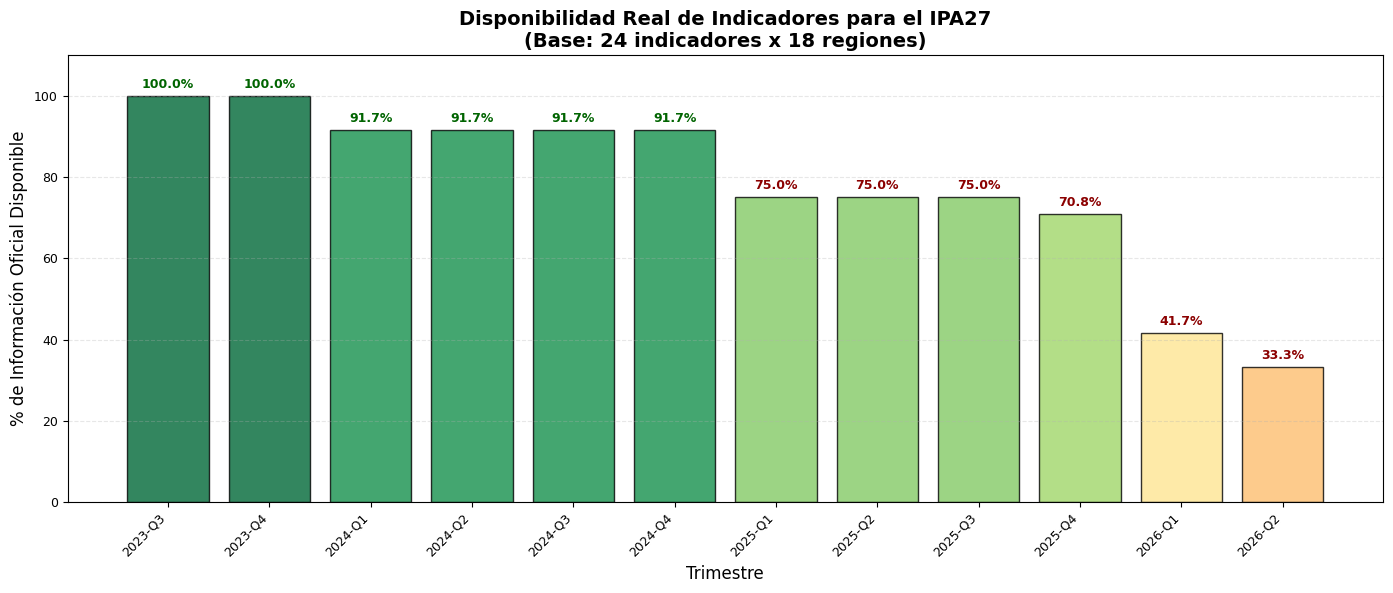

📊 Descenso de disponibilidad: De 100.0% en 2023Q3 a 33.3% en 2026Q2
👉 Este gráfico confirma que solo tenemos cubierto el 33.3% del objetivo mediante datos oficiales.


In [11]:
# %% CELDA: GRÁFICO DE DISPONIBILIDAD (Basado en Inventario Real)
import matplotlib.pyplot as plt
import pandas as pd

print("=" * 60)
print("ANÁLISIS DE DISPONIBILIDAD BASADO EN INVENTARIO")
print("=" * 60)

# 1. Obtener la fecha final de cada indicador (Lógica idéntica a tu Celda 10)
indicadores_fin = {}
for dominio, pilares in ESTRUCTURA.items():
    for pilar, indicadores in pilares.items():
        for ind in indicadores:
            freq, inicio, fin = detectar_frecuencia_y_rango(ind)
            if not fin: continue
            
            # Convertimos cualquier frecuencia al último MES en el que tiene datos
            if freq == 'M': # Mensual
                last_month = pd.Period(year=fin.year, month=fin.month, freq='M')
            elif freq == 'T': # Trimestral (ej: 2025Q3 -> 2025-09)
                last_month = fin.to_timestamp(how='end').to_period('M')
            elif freq == 'A': # Anual (ej: 2024 -> 2024-12)
                last_month = pd.Period(year=int(fin), month=12, freq='M')
            
            indicadores_fin[ind] = last_month

# 2. Crear línea de tiempo mensual (36 meses = 12 trimestres)
# El objetivo es el final del trimestre Q_OBJETIVO
target_month = Q_OBJETIVO.to_timestamp(how='end').to_period('M')
meses_plot = pd.period_range(end=target_month, periods=36, freq='M')

# 3. Calcular disponibilidad por mes
disponibilidad_mensual = []
total_teorico = len(ESTRUCTURA_FLAT := [i for d in ESTRUCTURA.values() for p in d.values() for i in p])

for mes in meses_plot:
    # Contamos cuántos indicadores siguen "vivos" en este mes
    vivos = sum(1 for ind, fin in indicadores_fin.items() if mes <= fin)
    disponibilidad_mensual.append((vivos / total_teorico) * 100)

df_dispo = pd.Series(disponibilidad_mensual, index=meses_plot)

# 4. Agrupar por trimestre
df_trimestral = df_dispo.resample('Q').mean()  # Con PeriodIndex, 'Q' funciona

# 5. Visualización
fig, ax = plt.subplots(figsize=(14, 6))

# Degradado de color según disponibilidad
colors = plt.cm.RdYlGn(df_trimestral.values / 100)

# Usar posiciones numéricas en vez de dejar que pandas formatee el eje
x = range(len(df_trimestral))
ax.bar(x, df_trimestral.values, color=colors, edgecolor='black', alpha=0.8, width=0.8)

# Etiquetas limpias: "2023-Q1", "2023-Q2", etc.
labels = [f"{p.year}-Q{p.quarter}" for p in df_trimestral.index]
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=9)

ax.set_title(
    f"Disponibilidad Real de Indicadores para el IPA27\n"
    f"(Base: {total_teorico} indicadores x 18 regiones)",
    fontsize=14, fontweight='bold'
)
ax.set_ylabel("% de Información Oficial Disponible", fontsize=12)
ax.set_xlabel("Trimestre", fontsize=12)
ax.set_ylim(0, 110)
ax.grid(axis='y', linestyle='--', alpha=0.3)

# Etiquetas de valor sobre las barras
for i, v in enumerate(df_trimestral.values):
    color = 'darkred' if v < 80 else 'darkgreen'
    ax.text(i, v + 2, f"{v:.1f}%", ha='center', fontweight='bold', color=color)

plt.tight_layout()
plt.show()

print(f"📊 Descenso de disponibilidad: De {df_trimestral.iloc[0]:.1f}% en {df_trimestral.index[0]} a {df_trimestral.iloc[-1]:.1f}% en {df_trimestral.index[-1]}")
print(f"👉 Este gráfico confirma que solo tenemos cubierto el {df_trimestral.iloc[-1]:.1f}% del objetivo mediante datos oficiales.")

## 2. Diagnóstico de Cobertura Temporal

Analizamos el estado real de cada serie para determinar qué acciones son necesarias:
- **OK**: La serie llega hasta 2025-Q3
- **EXTENDER**: Necesita nowcasting (ARIMA)
- **TRIMESTRALIZAR**: Serie anual que necesita Chow-Lin/Denton
- **TRIM+EXTENDER**: Anual que además necesita extensión

Este diagnóstico guía el procesamiento posterior.

In [12]:
# %% CELDA 2: DIAGNÓSTICO
print("=" * 60)
print("DIAGNÓSTICO DE COBERTURA TEMPORAL")
print("=" * 60)
print(f"Objetivo: {Q_OBJETIVO}\n")

diagnostico = []

# Función auxiliar para extraer indicador base del nombre de columna
def get_indicador_base(col):
    """Extrae el indicador base de una columna como 'SEG_BAL_AND' → 'SEG_BAL'"""
    parts = col.rsplit('_', 1)
    if len(parts) == 2 and parts[1] in REGIONES:
        return parts[0]
    return None

# Obtener indicadores únicos por frecuencia (usando AND como referencia)
def get_indicadores_unicos(df):
    inds = set()
    for col in df.columns:
        if col.startswith('AUX_'): continue
        if col.endswith('_AND'):
            ind_base = get_indicador_base(col)
            if ind_base:
                inds.add(ind_base)
    return sorted(inds)

# --- MENSUALES ---
print("📊 MENSUALES")
print("-" * 50)
for ind in get_indicadores_unicos(mensual):
    col = f"{ind}_AND"
    if col not in mensual.columns: continue
    
    serie = mensual[col].dropna()
    if len(serie) > 0:
        fin = serie.index.max()
        fin_q = pd.Period(year=fin.year, quarter=(fin.month - 1) // 3 + 1, freq='Q')
        estado = 'OK' if fin_q >= Q_OBJETIVO else 'EXTENDER'
        
        print(f"  {ind:<20} {fin:%Y-%m} (→ {fin_q}) {'✓' if estado == 'OK' else '⚠️'}")
        diagnostico.append({
            'Indicador': ind, 
            'Freq': 'M', 
            'Fin': str(fin_q),
            'Accion': estado
        })

# --- TRIMESTRALES ---
print(f"\n📊 TRIMESTRALES")
print("-" * 50)
for ind in get_indicadores_unicos(trimestral):
    col = f"{ind}_AND"
    if col not in trimestral.columns: continue
    
    serie = trimestral[col].dropna()
    if len(serie) > 0:
        fin = serie.index.max()
        estado = 'OK' if fin >= Q_OBJETIVO else 'EXTENDER'
        
        print(f"  {ind:<20} {fin} {'✓' if estado == 'OK' else '⚠️'}")
        diagnostico.append({
            'Indicador': ind, 
            'Freq': 'T', 
            'Fin': str(fin),
            'Accion': estado
        })

# --- ANUALES ---
print(f"\n📊 ANUALES")
print("-" * 50)
for ind in get_indicadores_unicos(anual):
    col = f"{ind}_AND"
    if col not in anual.columns: continue
    
    serie = anual[col].dropna()
    if len(serie) > 0:
        fin = serie.index.max()
        # Si el año es 2025, solo trimestralizar. Si es anterior, también extender.
        if fin >= 2026:
            estado = 'TRIMESTRALIZAR'
        else:
            estado = 'TRIM+EXTENDER'
        
        metodo = CHOWLIN_CONFIG.get(ind, None)
        metodo_str = f"(Chow-Lin: {metodo})" if metodo else "(Denton)"
        
        print(f"  {ind:<20} {fin} → {estado} {metodo_str}")
        diagnostico.append({
            'Indicador': ind, 
            'Freq': 'A', 
            'Fin': str(fin),
            'Accion': estado
        })

# --- RESUMEN ---
df_diag = pd.DataFrame(diagnostico)

print(f"\n" + "=" * 60)
print("RESUMEN")
print("=" * 60)
for accion in ['OK', 'EXTENDER', 'TRIMESTRALIZAR', 'TRIM+EXTENDER']:
    n = len(df_diag[df_diag['Accion'] == accion])
    if n > 0:
        indicadores = df_diag[df_diag['Accion'] == accion]['Indicador'].tolist()
        print(f"  {accion:<16}: {n} → {indicadores}")

print(f"\n✓ Diagnóstico completado")


DIAGNÓSTICO DE COBERTURA TEMPORAL
Objetivo: 2026Q2

📊 MENSUALES
--------------------------------------------------
  CON_OCI              2026-07 (→ 2026Q3) ✓
  EMP_SOC              2026-06 (→ 2026Q2) ✓
  GOB_DES              2026-04 (→ 2026Q2) ✓
  INF_TRA              2026-06 (→ 2026Q2) ✓
  INV_HIP              2026-05 (→ 2026Q2) ✓
  SOC_ASO              2026-07 (→ 2026Q3) ✓

📊 TRIMESTRALES
--------------------------------------------------
  ECO_COL_sal          2026Q1 ⚠️
  ECO_PIBpc            2025Q3 ⚠️
  ECO_RBHpc            2026Q2 ✓
  EDU_SUP              2026Q2 ✓
  INV_IED              2025Q4 ⚠️
  LIB_SEX              2025Q4 ⚠️
  SAL_SAT_enlazado     2025Q3 ⚠️
  SEG_BAL              2025Q4 ⚠️
  SEG_CRI              2025Q4 ⚠️
  VID_PAR              2026Q2 ✓

📊 ANUALES
--------------------------------------------------
  CON_IDI              2024 → TRIM+EXTENDER (Chow-Lin: {'rel': 'ECO_RBHpc', 'tipo': 'stock'})
  EDU_ABA              2024 → TRIM+EXTENDER (Chow-Lin: {'rel': 'EDU_SUP

In [13]:
# =============================================================================
# GUARDADO DE DATAFRAMES PREPARADOS PARA EL SIGUIENTE BLOQUE (Fase 2)
# =============================================================================
import os
import pickle

os.makedirs('data/processed', exist_ok=True)

mensual.to_csv('data/processed/ipa27_prep_mensual.csv')
trimestral.to_csv('data/processed/ipa27_prep_trimestral.csv')
anual.to_csv('data/processed/ipa27_prep_anual.csv')

# Guardar AUDIT_REGISTRY para su uso en la fase de exportación (02_3)
with open('data/processed/ipa27_audit_registry.pkl', 'wb') as f:
    pickle.dump(AUDIT_REGISTRY, f)

print("✓ Ficheros CSV de datos preparados guardados correctamente:")
print("  - data/processed/ipa27_prep_mensual.csv")
print("  - data/processed/ipa27_prep_trimestral.csv")
print("  - data/processed/ipa27_prep_anual.csv")
print("✓ Registro de trazabilidad (AUDIT_REGISTRY) guardado en 'data/processed/ipa27_audit_registry.pkl'")


✓ Ficheros CSV de datos preparados guardados correctamente:
  - data/processed/ipa27_prep_mensual.csv
  - data/processed/ipa27_prep_trimestral.csv
  - data/processed/ipa27_prep_anual.csv
✓ Registro de trazabilidad (AUDIT_REGISTRY) guardado en 'data/processed/ipa27_audit_registry.pkl'
